# 붓꽃 종류 군집화 하기

In [254]:
from sklearn import cluster
from sklearn import metrics
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import numpy as np

## 데이터 확인

각각의 속성은 cm 단위로 측정한 값
- 꽃받침 길이(sepal length)
- 너비(sepal width)
- 꽃잎 길이(petal length)
- 너비(petal width)

In [255]:
iris = load_iris()
iris.data[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

## 라벨 확인

In [256]:
labels = list(map(int, set(iris.target)))
print("labels :",labels)

labels : [0, 1, 2]


## 군집화

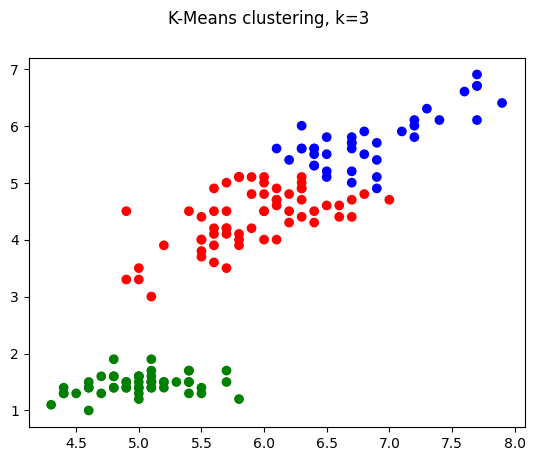

In [257]:
def kmeans_predict_plot(x, k):
    model = cluster.KMeans(n_clusters=k)
    model.fit(x)  
    labels = model.predict(x)
    colors = np.array(["red", "green", "blue"])
    plt.suptitle(f"K-Means clustering, k={k}")
    plt.scatter(x[:, 0], x[:, 2], c=colors[labels])
    plt.show()
    
    return model, labels

kmeans_model, y_pred = kmeans_predict_plot(iris.data, k=len(labels))

## 정확도 계산

### 라벨 매핑
클러스터는 랜덤하게 라벨 순서가 정해지므로 라벨 매핑 필요

In [258]:
from scipy.stats import mode

def remap_labels(y_true, y_pred):
    new_labels = np.zeros_like(y_pred)
    
    for i in range(len(set(y_pred))):
        mask = (y_pred == i)
        new_labels[mask] = mode(y_true[mask])[0]
    
    return new_labels

In [259]:
y_pred_fixed = remap_labels(iris.target, y_pred)

print(confusion_matrix(iris.target, y_pred_fixed))

[[50  0  0]
 [ 0 48  2]
 [ 0 14 36]]


### 정확도 출력

In [260]:
print("정밀도 :", precision_score(iris.target, y_pred_fixed, average='macro'))
print("재현율 :", recall_score(iris.target, y_pred_fixed, average='macro'))
print("정확도 :", accuracy_score(iris.target, y_pred_fixed))
print("F1 점수 :", f1_score(iris.target, y_pred_fixed, average='macro'))

정밀도 : 0.9071873231465761
재현율 : 0.8933333333333332
정확도 : 0.8933333333333333
F1 점수 : 0.8917748917748919


### ARI 방식

In [261]:
metrics.adjusted_rand_score(iris.target, y_pred)

0.7302382722834697